### Author:<br>
Name: Zhihao Cui<br>
Institute: School of Mathematics and Statistics <br>
NO: 20233002662

### MLP 手写数字识别 — 多分类实战

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [2]:
# 手写数字数据集：1797 个样本，8×8 像素=64维，10 类（0-9）
digits = load_digits()
X, y = digits.data, digits.target

print("=" * 50)
print("手写数字数据集")
print("=" * 50)
print(f"样本数量: {X.shape[0]}")
print(f"特征维度: {X.shape[1]} (8×8 像素展开)")
print(f"类别数: {len(np.unique(y))} (数字 0-9)")
print(f"每个类别的样本数: {[sum(y==i) for i in range(10)]}")
print()

手写数字数据集
样本数量: 1797
特征维度: 64 (8×8 像素展开)
类别数: 10 (数字 0-9)
每个类别的样本数: [178, 182, 177, 183, 181, 182, 181, 179, 174, 180]



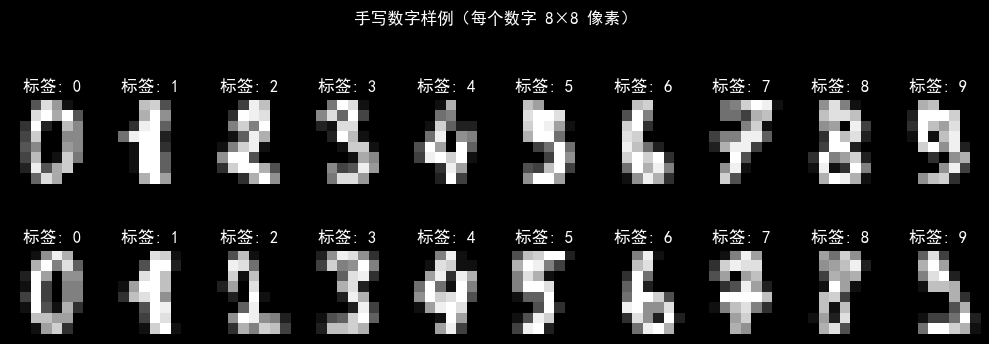

In [3]:
plt.figure(figsize=(10, 4))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"标签: {digits.target[i]}")
    plt.axis('off')
plt.suptitle("手写数字样例（每个数字 8×8 像素）")
plt.tight_layout()
plt.savefig("mlp_03_数字样例.png", dpi=150)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 标准化（对神经网络至关重要！）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# 网络结构：输入层(64) → 隐藏层(64) → 隐藏层(32) → 输出层(10)
# 输出层有 10 个神经元，每个对应一个数字（0-9），用 Softmax 转成概率
print("正在训练 MLP 模型（输入64→隐藏64→隐藏32→输出10）...")
print("这可能需要几秒钟...")

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 128, 64),   # 隐藏层
    activation='relu',             # 激活函数 ReLU
    solver='adam',                 # 优化器 Adam
    max_iter=300,                  # 最大迭代次数
    random_state=42,
    verbose=False                  # 设为 True 可以看到迭代过程
)

mlp.fit(X_train, y_train)

正在训练 MLP 模型（输入64→隐藏64→隐藏32→输出10）...
这可能需要几秒钟...


,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [6]:
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("模型评估")
print("=" * 50)
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"错误数: {sum(y_pred != y_test)} / {len(y_test)}")
print()

# 分类报告（每个类别的精确率、召回率、F1分数）
print("每个数字的分类表现:")
print(classification_report(y_test, y_pred, digits=4))


模型评估
测试集准确率: 0.9722 (97.22%)
错误数: 15 / 540

每个数字的分类表现:
              precision    recall  f1-score   support

           0     0.9811    0.9811    0.9811        53
           1     0.9800    0.9800    0.9800        50
           2     0.9038    1.0000    0.9495        47
           3     0.9615    0.9259    0.9434        54
           4     1.0000    1.0000    1.0000        60
           5     0.9846    0.9697    0.9771        66
           6     0.9811    0.9811    0.9811        53
           7     1.0000    0.9818    0.9908        55
           8     0.9535    0.9535    0.9535        43
           9     0.9655    0.9492    0.9573        59

    accuracy                         0.9722       540
   macro avg     0.9711    0.9722    0.9714       540
weighted avg     0.9729    0.9722    0.9723       540



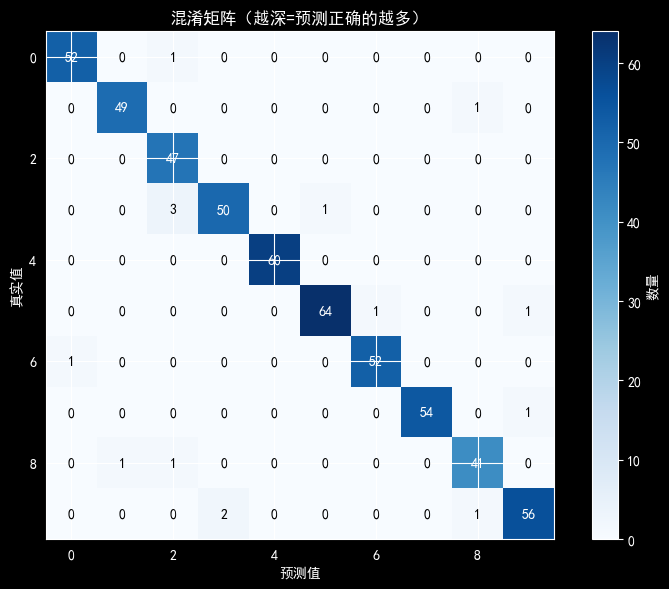

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label='数量')
plt.xlabel('预测值')
plt.ylabel('真实值')
plt.title('混淆矩阵（越深=预测正确的越多）')

# 在每个格子中标注数字
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig("mlp_03_混淆矩阵.png", dpi=150)
plt.show()


错误分析
总共错误: 15 个


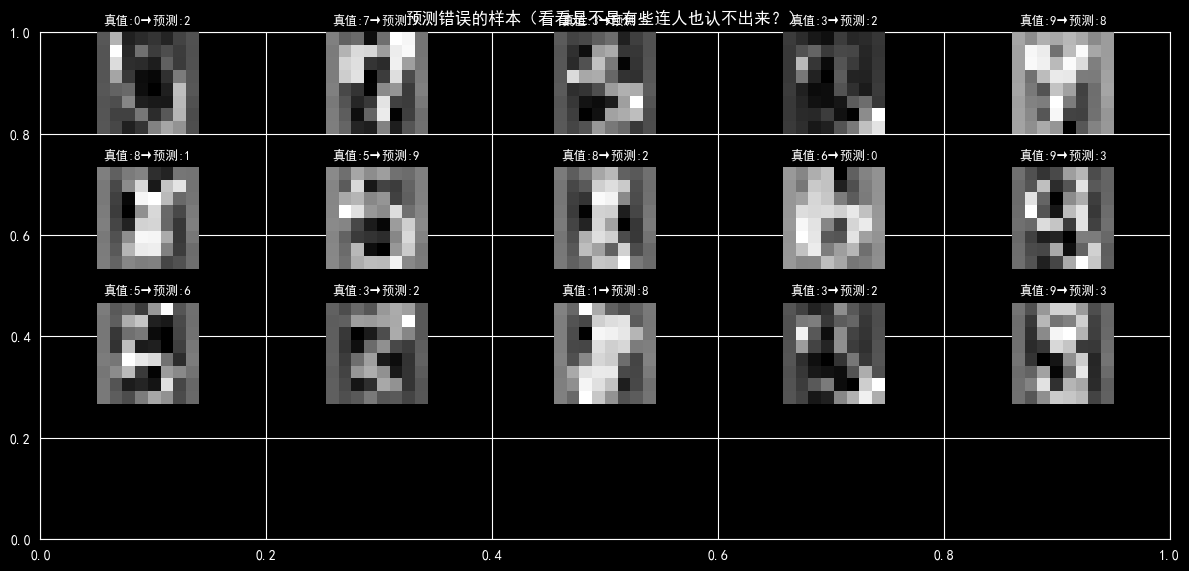

In [8]:
errors = np.where(y_pred != y_test)[0]

print("\n" + "=" * 50)
print("错误分析")
print("=" * 50)
print(f"总共错误: {len(errors)} 个")

if len(errors) > 0:
    plt.figure(figsize=(12, 6))
    plt.title("预测错误的样本（看看是不是有些连人也认不出来？）")
    n_show = min(20, len(errors))
    for i in range(n_show):
        plt.subplot(4, 5, i + 1)
        idx = errors[i]
        plt.imshow(X_test[idx].reshape(8, 8), cmap='gray')
        plt.title(f"真值:{y_test[idx]}→预测:{y_pred[idx]}", fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("mlp_03_错误样本.png", dpi=150)
    plt.show()

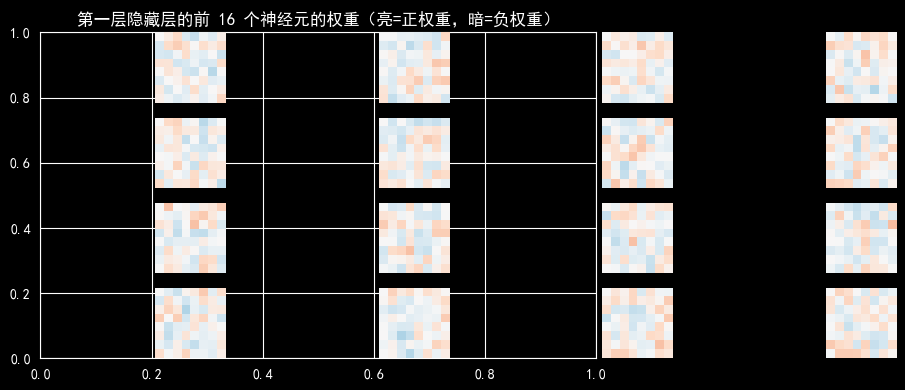

In [9]:
# MLP 第一层权重 shape: (输入维度, 第一个隐藏层神经元数)
W1 = mlp.coefs_[0]  # shape: (64, 64)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# 展示前 16 个隐藏神经元的权重图像
plt.title("第一层隐藏层的前 16 个神经元的权重（亮=正权重，暗=负权重）")
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(W1[:, i].reshape(8, 8), cmap='RdBu', vmin=-1, vmax=1)
    plt.axis('off')

plt.tight_layout()
plt.savefig("mlp_03_网络权重可视化.png", dpi=150)
plt.show()